<a href="https://colab.research.google.com/github/Matheesha-w/SE4050-Lab8/blob/main/Markov_Decision_Process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Markov Decision Process (MDP)

### Ransalu Senanayake

In [ ]:
import copy
import timeit
import numpy as np
import matplotlib.pyplot as pl
%matplotlib inline
from ipywidgets import interactive
import ipywidgets as widgets

Create the following grid world.

**States:** A 10x10 grid

**Actions:** Up, Down, Left, Right

**Tranistion probabilities:**
* 0.7 in the direction of action
* 0.1 in the three other directions
* The robot bounces back to the same state near edges

**Rewards:**
* (7,8) has a reward +10
* (2,7) has a reward +3
* (4,3) has a reward -5
* (7,3) has a reward -10
* No reward in other states

This example is based on Decision Making Under Uncertainty by M.J. Kochenderfer.

In [ ]:
#Let's define MDP paras
def createGrid10World():
    def xy2s(y, x):
        x = max(x, 0)
        y = max(y, 0)
        x = min(x, 9)
        y = min(y, 9)
        out = np.ravel_multi_index(np.array([x,y]), (10,10))
        return out

    def s2xy(s):
        x, y = np.unravel_index(s, (10,10))
        return y, x

    def gridPlot(ax, im, title='', cmap='Blues'):
        pl.imshow(im, interpolation='none', cmap=cmap, origin='lower')
        pl.colorbar()
        ax.set_xticks(np.arange(0, 10, 1));
        ax.set_yticks(np.arange(0, 10, 1));
        ax.set_xticklabels(np.arange(0, 10, 1));
        ax.set_yticklabels(np.arange(0, 10, 1));
        ax.set_xticks(np.arange(-.5, 10, 1), minor=True);
        ax.set_yticks(np.arange(-.5, 10, 1), minor=True);
        ax.grid(which='minor', color='w', linestyle='-', linewidth=1)
        pl.title(title);
        return

    A = ['left', 'right', 'up', 'down']
    S = np.arange(100)
    T = np.zeros((len(S), len(A), len(S)))
    R = np.zeros((len(S), len(A)))
    for s in S:
        x, y = s2xy(s)
        if x == 2 and y == 7:
            R[s, :] = 3
        elif x == 7 and y == 8:
            R[s, :] = 10
        else:
            if x == 7 and y == 3:
                R[s, :] = -10
            elif x == 4 and y == 3:
                R[s, :] = -5
            elif x == 0:
                if y == 0 or y == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 0] = -0.7
            elif x == 9:
                if y == 0 or y == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 1] = -0.7
            elif y == 0:
                if x == 0 or x == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 3] = -0.7
            elif y == 9:
                if x == 0 or x == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 2] = -0.7

            for a in A:
                if a == 'left':
                    T[s, 0, xy2s(x - 1, y)] += 0.7
                    T[s, 0, xy2s(x + 1, y)] += 0.1
                    T[s, 0, xy2s(x, y - 1)] += 0.1
                    T[s, 0, xy2s(x, y + 1)] += 0.1
                elif a == 'right':
                    T[s, 1, xy2s(x + 1, y)] += 0.7
                    T[s, 1, xy2s(x - 1, y)] += 0.1
                    T[s, 1, xy2s(x, y - 1)] += 0.1
                    T[s, 1, xy2s(x, y + 1)] += 0.1
                elif a == 'up':
                    T[s, 2, xy2s(x, y + 1)] += 0.7
                    T[s, 2, xy2s(x, y - 1)] += 0.1
                    T[s, 2, xy2s(x - 1, y)] += 0.1
                    T[s, 2, xy2s(x + 1, y)] += 0.1
                elif a == 'down':
                    T[s, 3, xy2s(x, y - 1)] += 0.7
                    T[s, 3, xy2s(x, y + 1)] += 0.1
                    T[s, 3, xy2s(x - 1, y)] += 0.1
                    T[s, 3, xy2s(x + 1, y)] += 0.1

    for a, c_x, c_y in [(0,0,0), (0,0,9),(1,9,0),(1,9,9),(2,0,9),(2,9,9),(3,0,0),(3,9,0)]:
        R[xy2s(c_x,c_y),a] = -0.8

    discount = 0.9

    nextStates = {}
    for si in range(len(S)):
        for ai in range(len(A)):
            nextStates[(si,ai)] = np.where((T[si, ai, :] != 0) == True)[0]

    return {'S':S, 'A':A, 'T':T, 'R':R, 'discount':discount, 'nextStates':nextStates, 'gridPlot':gridPlot, 'xy2s':xy2s, 's2xy':s2xy}

In [ ]:
class MDP():
    def __init__(self):
        pass

    def inbuilt_init(self, mdp_dict):
        self.S = mdp_dict['S']
        self.A = mdp_dict['A']
        self.T = mdp_dict['T']
        self.R = mdp_dict['R']
        self.discount = mdp_dict['discount']
        self.nextStates = mdp_dict['nextStates']
        self.gridPlot = mdp_dict['gridPlot']
        self.xy2s = mdp_dict['xy2s']
        self.s2xy = mdp_dict['s2xy']

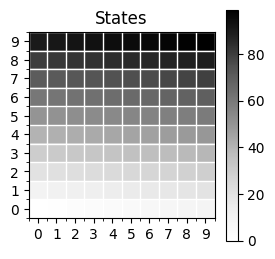

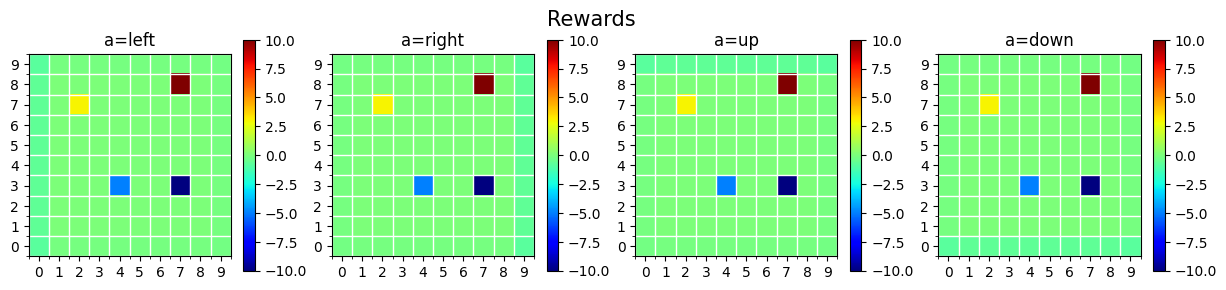

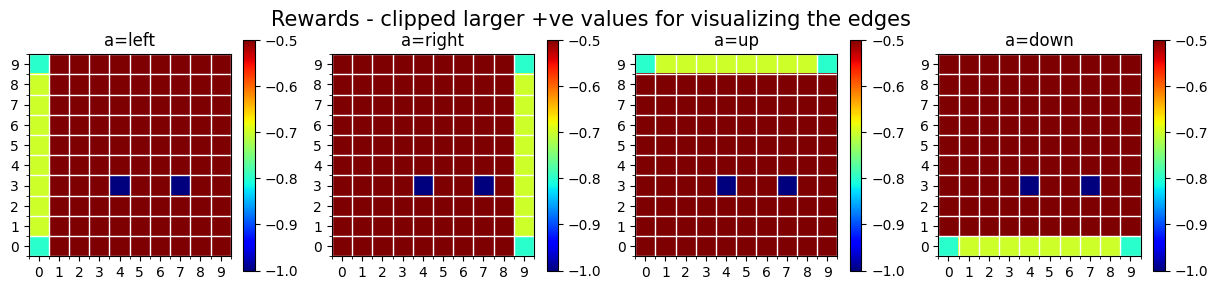

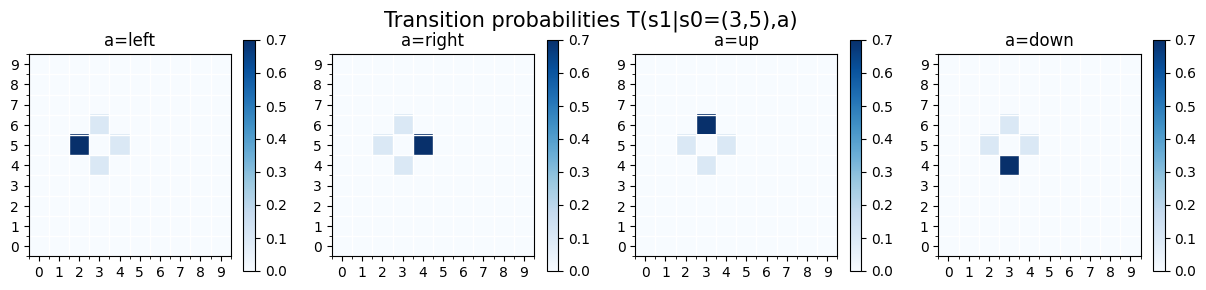

In [ ]:
#Define the MDP
mdp = MDP()
mdp.inbuilt_init(mdp_dict=createGrid10World())

#Plot states
pl.figure(figsize=(3,3))
mdp.gridPlot(ax=pl.gca(), im=mdp.S.reshape((10,10)), title='States', cmap='Greys')

#Plot rewards
pl.figure(figsize=(15,3))
pl.suptitle('Rewards', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=mdp.R[:,a].reshape((10,10)), title='a='+mdp.A[a], cmap='jet')
pl.show()

#Plot rewards
pl.figure(figsize=(15,3))
pl.suptitle('Rewards - clipped larger +ve values for visualizing the edges', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=np.clip(mdp.R[:,a].reshape((10,10)), -1, -0.5), title='a='+mdp.A[a], cmap='jet')
pl.show()

#Plot rewards
s0_x, s0_y = 3, 5
s0 = mdp.xy2s(s0_x, s0_y)
pl.figure(figsize=(15,3))
pl.suptitle('Transition probabilities T(s1|s0=({},{}),a)'.format(s0_x, s0_y), fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=mdp.T[s0,a,:].reshape((10,10)), title='a='+mdp.A[a], cmap='Blues')
pl.show()

In [ ]:
#An interactive plot of transition probabilities
def f(s0_x, s0_y, action):
    a = mdp.A.index(action)
    s0 = mdp.xy2s(int(s0_x), int(s0_y))
    pl.figure(figsize=(6,6))
    title = 'Transition probabilities T(s1|s0=({},{}),a={})'.format(int(s0_x),int(s0_y),action)
    mdp.gridPlot(ax=pl.gca(), im=mdp.T[s0,a,:].reshape((10,10)), title=title, cmap='Blues')
    pl.show()

interactive_plot = interactive(f, s0_x='4', s0_y='5', action=widgets.ToggleButtons(options=['left', 'right', 'up', 'down']))
interactive_plot

interactive(children=(Text(value='4', description='s0_x'), Text(value='5', description='s0_y'), ToggleButtons(…

### 1. Policy evaluation

Computing the utility, U.

$U^\pi_k(s) = R(s, \pi(s)) + \gamma \sum_{s'} T(s' \mid s, \pi(s))U^\pi_{k-1}(s')$

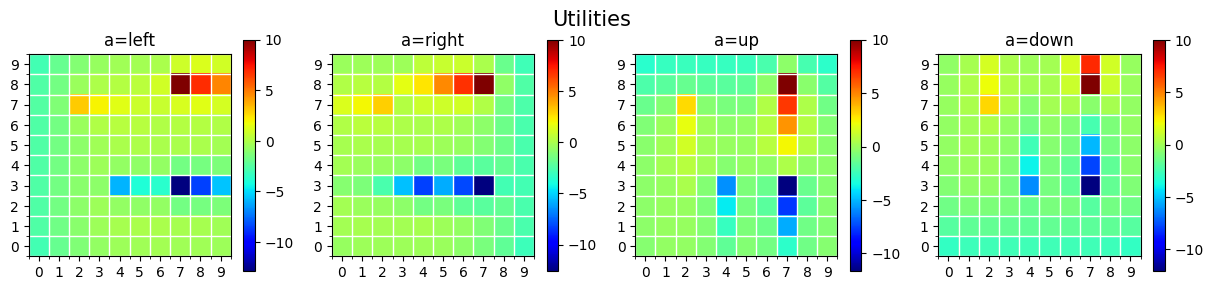

In [ ]:
def iterativePolicyEvaluation(mdp, policy, numIterations=10):
    U = np.zeros(len(mdp.S))
    U_old = copy.copy(U)
    for t in range(numIterations):
        for s in mdp.S:
            a = int(policy) if np.isscalar(policy) else int(policy[s])
            U[s] = mdp.R[s, a] + mdp.discount * np.sum(mdp.T[s, a, :] * U_old)
        U_old = copy.copy(U)
    return U

numIterations = 5
pl.figure(figsize=(15,3))
pl.suptitle('Utilities', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    U = iterativePolicyEvaluation(mdp=mdp, policy=a, numIterations=numIterations)
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='a='+mdp.A[a], cmap='jet')
pl.show()
#print(np.round(U.reshape(10,10),3))

In [ ]:
def f(action, numIter=1):
    U = iterativePolicyEvaluation(mdp, policy=mdp.A.index(action), numIterations=numIter)
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
    pl.show()

interactive_plot = interactive(f, action=widgets.ToggleButtons(options=['left', 'right', 'up', 'down']),
                               numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(ToggleButtons(description='action', options=('left', 'right', 'up', 'down'), value='left…

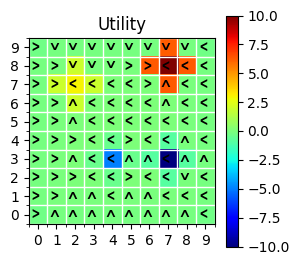

In [ ]:
#Value iteration
def valueIteration(mdp, numIterations=1):
    U = np.zeros(len(mdp.S))
    U_old = copy.copy(U)
    for t in range(numIterations):
        for s in mdp.S:
            U[s] = np.max(mdp.R[s, :] + mdp.discount * mdp.T[s, :, :].dot(U_old))
        U_old = copy.copy(U)
    return U

def policyExtration(mdp, U):
    policy = np.zeros(len(mdp.S))
    for s in mdp.S:
        policy[s] = np.argmax(mdp.R[s, :] + mdp.discount * mdp.T[s, :, :].dot(U))
    return policy

U = valueIteration(mdp, numIterations=2)
policy = policyExtration(mdp, U=U)
pl.figure(figsize=(3,3))
mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
for s in range(100):
    x, y = mdp.s2xy(s)
    if policy[s] == 0:
        m='\u02C2'
    elif policy[s] == 1:
        m='\u02C3'
    elif policy[s] == 2:
        m='\u02C4'
    elif policy[s] == 3:
        m='\u02C5'
    pl.text(x-0.5,y-1,m,color='k',size=20)
pl.show()

In [ ]:
def f(numIter=1):
    start_time = timeit.default_timer()
    U = valueIteration(mdp, numIterations=numIter)
    policy = policyExtration(mdp, U=U)
    elapsed = timeit.default_timer() - start_time
    print('time=', np.round(elapsed*1000,2))
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
    for s in range(100):
        x, y = mdp.s2xy(s)
        if policy[s] == 0:
            m='\u02C2'
        elif policy[s] == 1:
            m='\u02C3'
        elif policy[s] == 2:
            m='\u02C4'
        elif policy[s] == 3:
            m='\u02C5'
        pl.text(x-0.5,y-1,m,color='k',size=20)
    pl.show()

interactive_plot = interactive(f, numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(IntSlider(value=0, description='numIter', max=20), Output()), _dom_classes=('widget-inte…

### 2. Policy iteration

Policy evaluation can be used in policy iteration:
1. Given the current policy, compute U
2. Using U, compute a new policy

In [ ]:
def policyIteration(mdp, numIterations=1):
    U_pi_k = np.zeros(len(mdp.S)) #initial values
    pi_k = np.random.randint(low=0,high=4,size=len(mdp.S),dtype=int) #initial policy
    pi_kp1 = copy.copy(pi_k)
    for t in range(numIterations):
        #Policy evaluation: compute U_pi_k
        pi_k = copy.copy(pi_kp1)
        U_pi_k = iterativePolicyEvaluation(mdp, policy=pi_k, numIterations=50)
        #Policy improvement
        pi_kp1 = policyExtration(mdp, U=U_pi_k).astype(int)
    return U_pi_k, pi_kp1

U_pi_k, pi_kp1 = policyIteration(mdp, numIterations=2)

In [ ]:
def f(numIter=1):
    start_time = timeit.default_timer()
    # code you want to evaluate
    value, policy = policyIteration(mdp, numIterations=numIter)
    elapsed = timeit.default_timer() - start_time
    print('time=', np.round(elapsed*1000,2))
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=value.reshape(10,10), title='Utility', cmap='jet')
    for s in range(100):
        x, y = mdp.s2xy(s)
        if policy[s] == 0:
            m='\u02C2'
        elif policy[s] == 1:
            m='\u02C3'
        elif policy[s] == 2:
            m='\u02C4'
        elif policy[s] == 3:
            m='\u02C5'
        pl.text(x-0.5,y-1,m,color='k',size=20)
    pl.show()

interactive_plot = interactive(f, numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(IntSlider(value=0, description='numIter', max=20), Output()), _dom_classes=('widget-inte…

## Model-Based vs Model-Free

Comparing value iteration and policy iteration (model-based) with Q-learning (model-free) on the same 10x10 grid world. Execution time and convergence are measured for each.

### Model-based: value iteration and policy iteration

In [ ]:
def valueIterationConv(mdp, tol=1e-6, maxIter=1000):
    U = np.zeros(len(mdp.S))
    deltas = []
    for t in range(maxIter):
        U_new = np.max(mdp.R + mdp.discount * mdp.T.dot(U), axis=1)
        delta = np.max(np.abs(U_new - U))
        deltas.append(delta)
        U = U_new
        if delta < tol:
            break
    policy = np.argmax(mdp.R + mdp.discount * mdp.T.dot(U), axis=1)
    return U, policy, deltas

def policyIterationConv(mdp, maxIter=100, seed=0):
    rng = np.random.default_rng(seed)
    nS = len(mdp.S)
    pi = rng.integers(0, len(mdp.A), size=nS)
    changes = []
    for t in range(maxIter):
        # evaluate current policy (solve linear system)
        T_pi = mdp.T[np.arange(nS), pi, :]
        R_pi = mdp.R[np.arange(nS), pi]
        U = np.linalg.solve(np.eye(nS) - mdp.discount * T_pi, R_pi)
        # improve policy
        pi_new = np.argmax(mdp.R + mdp.discount * mdp.T.dot(U), axis=1)
        n_changed = int(np.sum(pi_new != pi))
        changes.append(n_changed)
        pi = pi_new
        if n_changed == 0:
            break
    return U, pi, changes

start = timeit.default_timer()
U_vi, pi_vi, vi_deltas = valueIterationConv(mdp)
time_vi = timeit.default_timer() - start

start = timeit.default_timer()
U_pi, pi_pi, pi_changes = policyIterationConv(mdp)
time_pi = timeit.default_timer() - start

print('Value Iteration : converged in {:4d} iterations, time = {:8.2f} ms'.format(len(vi_deltas), time_vi*1000))
print('Policy Iteration: converged in {:4d} iterations, time = {:8.2f} ms'.format(len(pi_changes), time_pi*1000))
print('Max |U_VI - U_PI| =', np.round(np.max(np.abs(U_vi - U_pi)), 6))
print('Same policy (VI vs PI):', np.mean(pi_vi == pi_pi)*100, '% of states')

Value Iteration : converged in   61 iterations, time =     2.53 ms
Policy Iteration: converged in    7 iterations, time =     2.01 ms
Max |U_VI - U_PI| = 2e-06
Same policy (VI vs PI): 100.0 % of states


### Model-free: Q-learning

The agent does not use T or R. It only gets the next state and reward from `step()`. The +3 and +10 states end the episode. The value iteration result is only used to check how close Q-learning gets.

In [ ]:
class GridEnv:
    def __init__(self, mdp, seed=0):
        self._R = mdp.R
        self.nS, self.nA = mdp.T.shape[0], mdp.T.shape[1]
        self._cumT = np.cumsum(mdp.T, axis=2)
        self._terminal = (mdp.T.sum(axis=2) == 0).all(axis=1)
        self.rng = np.random.default_rng(seed)

    def reset(self):
        self.s = int(self.rng.integers(self.nS))
        return self.s

    def step(self, a):
        r = self._R[self.s, a]
        if self._terminal[self.s]:
            return self.s, r, True
        s_next = int(np.searchsorted(self._cumT[self.s, a], self.rng.random()))
        self.s = min(s_next, self.nS - 1)
        return self.s, r, False


def qLearning(env, gamma, U_star, pi_star, episodes=5000, max_steps=200, alpha_power=0.6,
              eps_start=1.0, eps_end=0.2, seed=0):
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.nS, env.nA))
    N = np.zeros((env.nS, env.nA))
    errors, max_errors, agreement, steps_total = [], [], [], 0
    for ep in range(episodes):
        eps = max(eps_end, eps_start - (eps_start - eps_end) * ep / (0.5 * episodes))
        s = env.reset()
        for t in range(max_steps):
            if rng.random() < eps:
                a = int(rng.integers(env.nA))
            else:
                a = int(rng.choice(np.flatnonzero(Q[s] == Q[s].max())))
            s_next, r, done = env.step(a)
            N[s, a] += 1
            alpha = 1.0 / N[s, a] ** alpha_power
            target = r if done else r + gamma * np.max(Q[s_next])
            Q[s, a] += alpha * (target - Q[s, a])
            steps_total += 1
            s = s_next
            if done:
                break
        err = np.abs(Q.max(axis=1) - U_star)
        errors.append(np.mean(err))
        max_errors.append(np.max(err))
        agreement.append(np.mean(Q.argmax(axis=1) == pi_star) * 100)
    return Q, np.array(errors), np.array(max_errors), np.array(agreement), steps_total

env = GridEnv(mdp, seed=0)
start = timeit.default_timer()
Q_ql, ql_errors, ql_max_errors, ql_agree, ql_steps = qLearning(env, mdp.discount, U_vi, pi_vi, episodes=5000)
time_ql = timeit.default_timer() - start
pi_ql = Q_ql.argmax(axis=1)

# converged when mean value error stays below TOL
TOL = 0.1
below = ql_errors < TOL
conv_ep = next((i for i in range(len(below)) if below[i:].all()), None)

Q_star = mdp.R + mdp.discount * mdp.T.dot(U_vi)
q_sorted = np.sort(Q_star, axis=1)
clear_states = (q_sorted[:, -1] - q_sorted[:, -2]) >= 0.05

print('Q-Learning: {} episodes, {} steps, time = {:.2f} ms'.format(len(ql_errors), ql_steps, time_ql*1000))
print('Mean value error = {:.4f}, max = {:.4f}'.format(ql_errors[-1], ql_max_errors[-1]))
print('Policy match = {:.1f}% (all states), {:.1f}% (excluding near-tie states)'.format(
    ql_agree[-1], np.mean((pi_ql == pi_vi)[clear_states]) * 100))
print('Converged at episode:', conv_ep)

Q-Learning: 5000 episodes, 134859 steps, time = 2516.85 ms
Mean value error = 0.0556, max = 0.5079
Policy match = 90.0% (all states), 98.6% (excluding near-tie states)
Converged at episode: 1733


### Results

,Approach,Algorithm,Iterations/Episodes to converge,Time (ms),Mean |V - U*|,Policy match (%)
0,Model-Based,Value Iteration,61,2.53,0.0000,100.0
1,Model-Based,Policy Iteration,7,2.01,0.0000,100.0
2,Model-Free,Q-Learning,1733,2516.85,0.0556,90.0


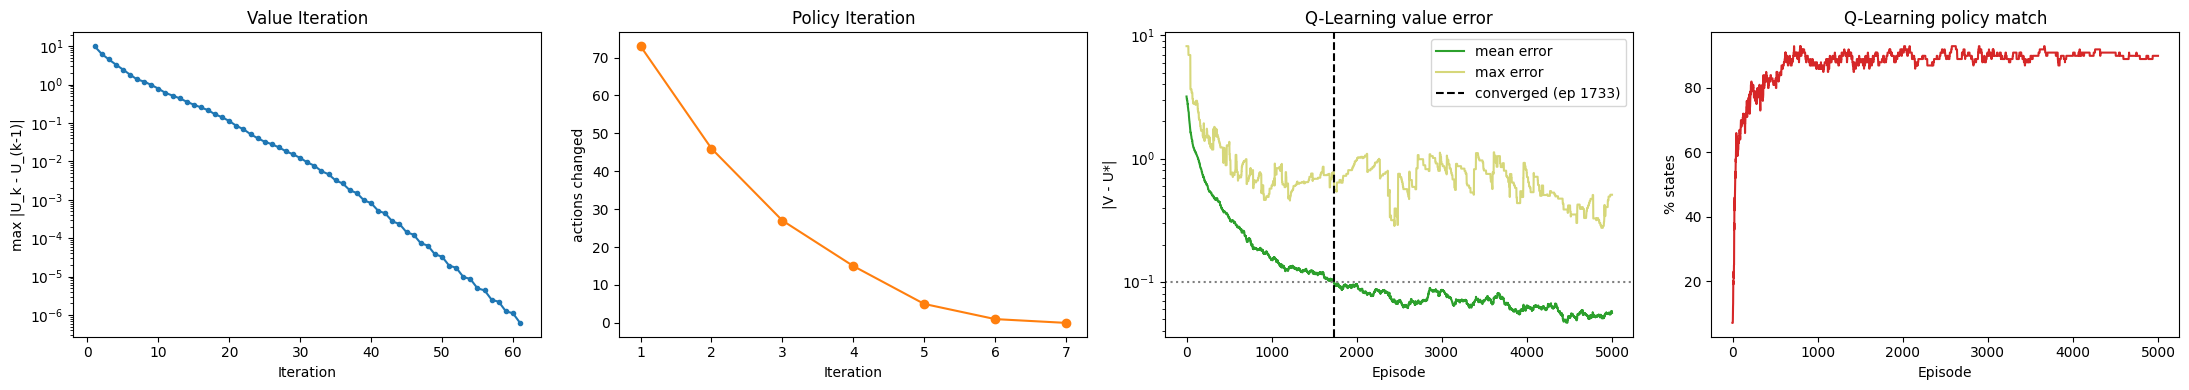

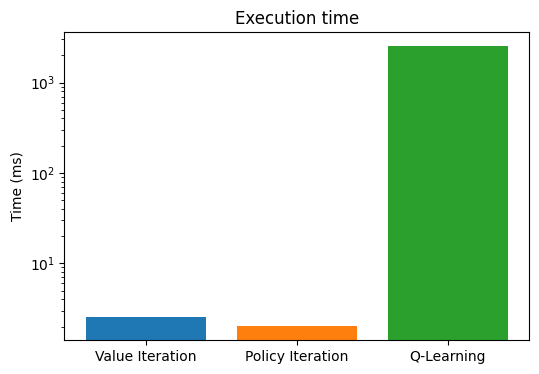

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Approach': ['Model-Based', 'Model-Based', 'Model-Free'],
    'Algorithm': ['Value Iteration', 'Policy Iteration', 'Q-Learning'],
    'Iterations/Episodes to converge': [len(vi_deltas), len(pi_changes), conv_ep],
    'Time (ms)': [round(time_vi*1000, 2), round(time_pi*1000, 2), round(time_ql*1000, 2)],
    'Mean |V - U*|': [0.0, round(float(np.mean(np.abs(U_pi - U_vi))), 6), round(float(ql_errors[-1]), 4)],
    'Policy match (%)': [100.0, round(np.mean(pi_pi == pi_vi)*100, 1), round(ql_agree[-1], 1)],
})
display(results)

fig, axs = pl.subplots(1, 4, figsize=(22, 4))
axs[0].semilogy(np.arange(1, len(vi_deltas)+1), vi_deltas, 'o-', ms=3)
axs[0].set_title('Value Iteration'); axs[0].set_xlabel('Iteration'); axs[0].set_ylabel('max |U_k - U_(k-1)|')
axs[1].plot(np.arange(1, len(pi_changes)+1), pi_changes, 'o-', color='tab:orange')
axs[1].set_title('Policy Iteration'); axs[1].set_xlabel('Iteration'); axs[1].set_ylabel('actions changed')
axs[2].semilogy(ql_errors, color='tab:green', label='mean error')
axs[2].semilogy(ql_max_errors, color='tab:olive', alpha=0.6, label='max error')
axs[2].axhline(TOL, ls=':', color='gray')
if conv_ep is not None:
    axs[2].axvline(conv_ep, ls='--', color='k', label='converged (ep {})'.format(conv_ep))
axs[2].legend()
axs[2].set_title('Q-Learning value error'); axs[2].set_xlabel('Episode'); axs[2].set_ylabel('|V - U*|')
axs[3].plot(ql_agree, color='tab:red')
axs[3].set_title('Q-Learning policy match'); axs[3].set_xlabel('Episode'); axs[3].set_ylabel('% states')
pl.tight_layout(); pl.show()

pl.figure(figsize=(6, 4))
pl.bar(['Value Iteration', 'Policy Iteration', 'Q-Learning'], [time_vi*1000, time_pi*1000, time_ql*1000],
       color=['tab:blue', 'tab:orange', 'tab:green'])
pl.yscale('log'); pl.ylabel('Time (ms)'); pl.title('Execution time')
pl.show()

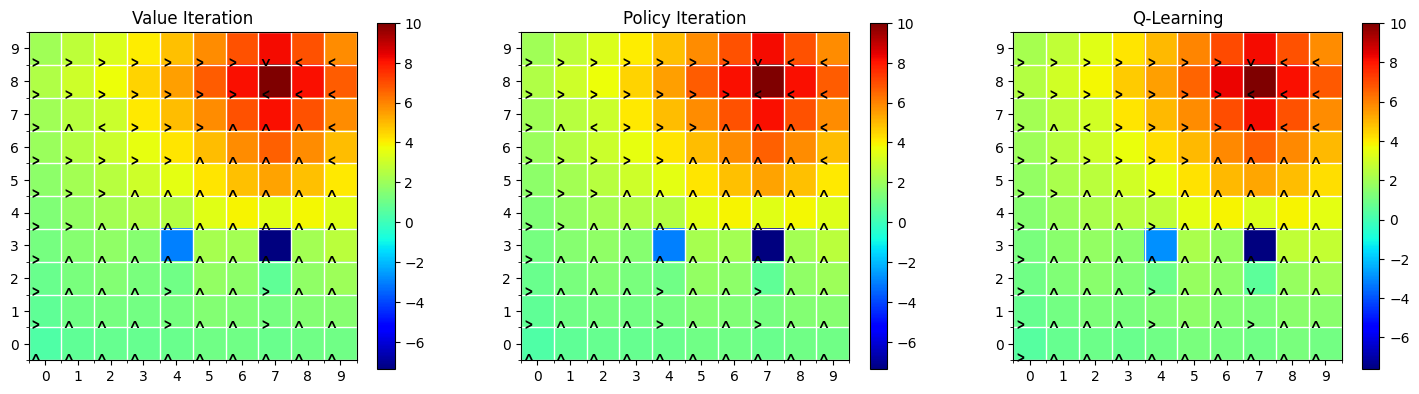

In [ ]:
def plotPolicy(ax, U, policy, title):
    mdp.gridPlot(ax=ax, im=U.reshape(10,10), title=title, cmap='jet')
    arrows = ['\u02C2', '\u02C3', '\u02C4', '\u02C5']
    for s in range(100):
        x, y = mdp.s2xy(s)
        ax.text(x-0.5, y-1, arrows[int(policy[s])], color='k', size=20)

pl.figure(figsize=(18, 4.5))
ax = pl.subplot(1, 3, 1); plotPolicy(ax, U_vi, pi_vi, 'Value Iteration')
ax = pl.subplot(1, 3, 2); plotPolicy(ax, U_pi, pi_pi, 'Policy Iteration')
ax = pl.subplot(1, 3, 3); plotPolicy(ax, Q_ql.max(axis=1), pi_ql, 'Q-Learning')
pl.show()

### Difference between model-based and model-free

Model-based methods (value iteration, policy iteration) use the transition probabilities and rewards directly. They update every state using the expected value over next states, so they converge in few iterations and give the exact optimal policy. But they need the model, and each sweep gets expensive when the number of states is large.

Model-free methods (Q-learning) do not need the model. They learn Q(s,a) from sampled transitions while exploring. Each sample is noisy, so many more episodes are needed and the result is only approximate (states that are rarely visited or have almost equal actions can be wrong). The advantage is that it works when the model is unknown, and it can be extended to neural networks (DQN).

In this experiment value iteration and policy iteration finished in milliseconds, while Q-learning needed thousands of episodes and a few seconds to get close to the same values.